# 04 · The Arena

Six tests. Eight conditions, each as a null pair and an effect pair. Ten thousand replications
per cell. Every test sees **byte-identical data** within a scenario, so a difference between two
rows of the same scenario is a difference between the tests and not between the draws.

The ideal is simple and strict:

- **under the null**, a false-positive rate of exactly α = 0.05 — no higher, and not much lower
  either, because a conservative test is spending power it could have kept;
- **under a real effect**, power as high as possible — but *only* readable for a test that
  passed the first bar.

A cold run of the full arena takes about nine and a half minutes on a 2-CPU machine, so results
are cached against a hash of the configuration. Change a scenario, a seed, α or a replication
count and it recomputes; otherwise it loads.

In [1]:
# Make the project importable whether this notebook is run from notebooks/ or the repo root.
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import time

from src.config import get_settings, save_results
from src.evaluation.comparison import run_arena, scoreboard, verdict
from src.visualisation import (
    plot_arena_heatmap,
    plot_false_positive_rates,
    plot_power,
    save_figure,
)

settings = get_settings()
alpha, n_reps = settings.alpha, settings.reps.n_reps
figures: dict[str, str] = {}

started = time.time()
arena = run_arena(settings=settings, progress=True)
print(f"\n{len(arena)} cells in {time.time() - started:.1f}s   "
      f"({n_reps:,} replications each, mc_se near α = {(0.05 * 0.95 / n_reps) ** 0.5:.4f})")

  loaded from cache: arena_18bb29e770d6f6eb.csv

96 cells in 0.0s   (10,000 replications each, mc_se near α = 0.0022)


## The scoreboard, part one: does the test deliver the α it promises?

Every number below should be 0.05. Read anything more than about three Monte Carlo standard
errors away as real.

In [3]:
scoreboard(arena, "fpr").round(4)

test,student,welch,mann_whitney,permutation,bootstrap,bayesian
scenario,,,,,,
contaminated_outliers::null,0.0432,0.0426,0.0488,0.0490,0.0204,0.0407
heavy_tailed::null,0.0459,0.0458,0.0462,0.0496,0.0421,0.0445
normal_equal_var::null,0.0496,0.0495,0.0500,0.0487,0.0486,0.0489
normal_unequal_var_equal_n::null,0.0550,0.0524,0.0735,0.0557,0.0513,0.0528
normal_unequal_var_unequal_n::null,0.3753,0.0477,0.1721,0.0509,0.0441,0.0488
skewed_extreme_unequal::null,0.1538,0.1767,0.3416,0.1301,0.1592,0.1718
skewed_small_n::null,0.0402,0.0372,0.0430,0.0496,0.0280,0.0337
skewed_unequal_n::null,0.0502,0.0897,0.0492,0.0500,0.0836,0.0858


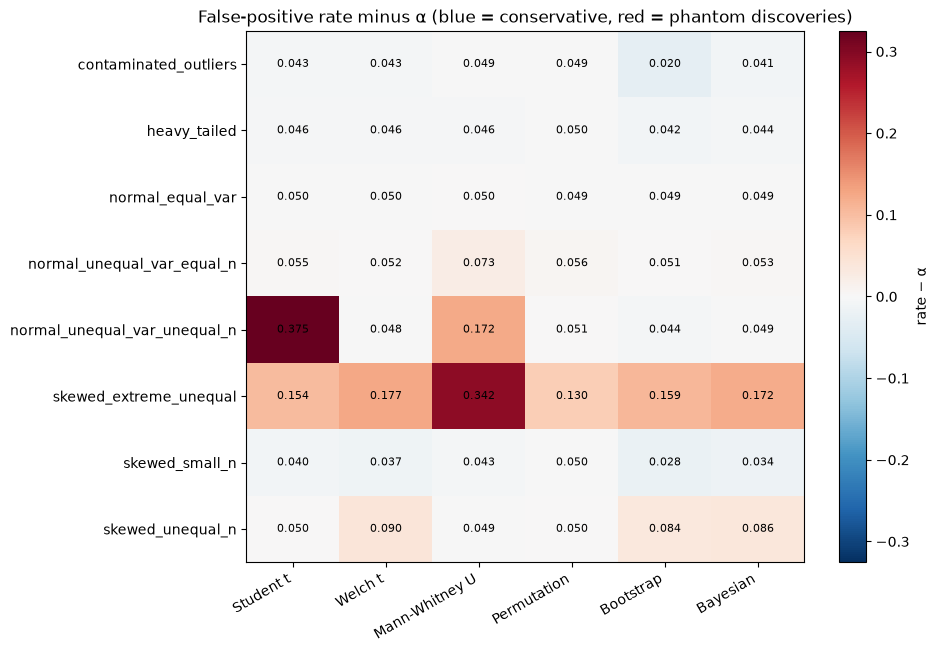

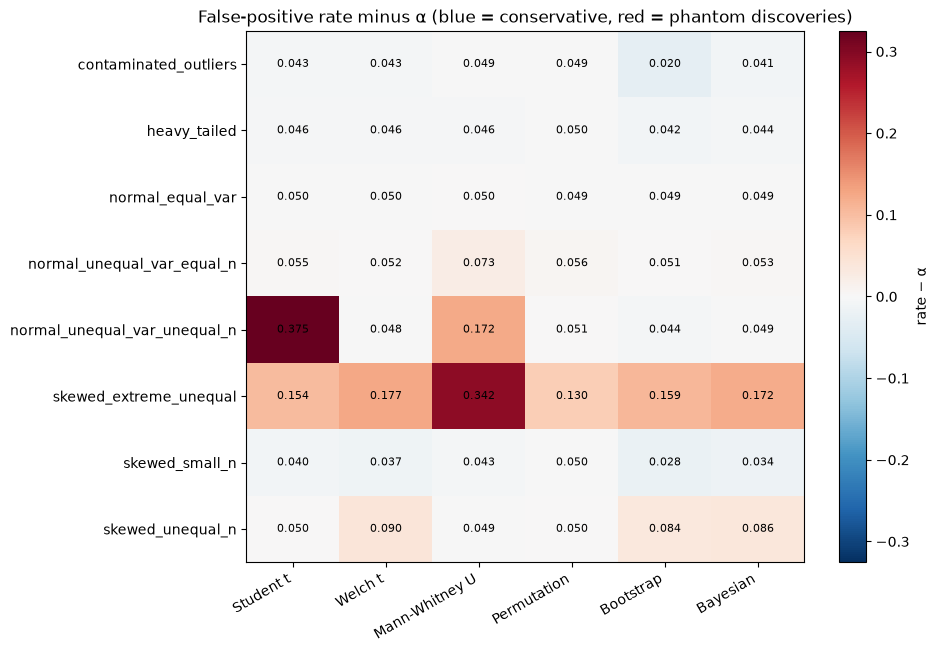

In [4]:
fig = plot_arena_heatmap(arena, metric="fpr", alpha=alpha)
figures["fpr_heatmap"] = save_figure(fig, "04_fpr_heatmap")
fig

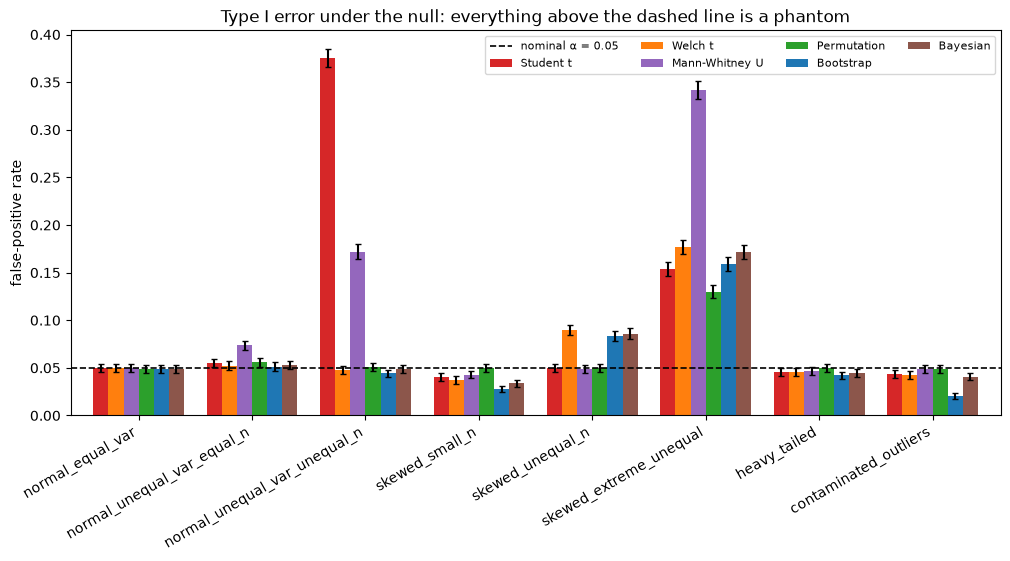

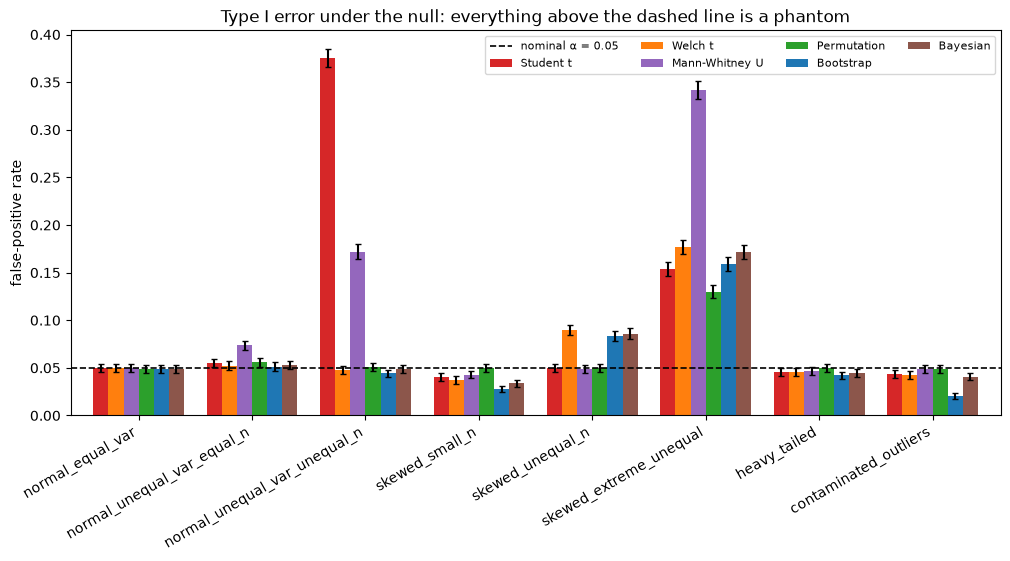

In [5]:
fig = plot_false_positive_rates(arena, alpha=alpha)
figures["fpr_bars"] = save_figure(fig, "04_fpr_bars")
fig

Red is a test inventing discoveries. Blue is a test being over-cautious. White is correct.

Four things are visible at once:

1. **`normal_unequal_var_unequal_n` is Student's disaster column** and nobody else's. This is the
   showpiece from notebook 02.
2. **`skewed_unequal_n` moves the problem to Welch** (and to the Bayesian contender, which is
   Welch's Bayesian cousin here). Student happens to be nearer nominal in that row. Neither
   t-test is safe everywhere; they are unsafe in different places.
3. **`skewed_extreme_unequal` is red for everyone.** Skewness 14 concentrated in the smaller
   group defeats every mean-based test in the arena. The permutation test is the least-bad of
   the six there, which is a much weaker claim than "it works".
4. **Mann-Whitney's red cells are not miscalibration.** In the unequal-variance rows the two
   distributions genuinely differ, so a test of stochastic equality is correct to reject. Its
   number belongs in a different column of your mental table than the others'.

## The scoreboard, part two: power

Now the second question — but only for the tests that passed the first.

In [6]:
scoreboard(arena, "power").round(4)

test,student,welch,mann_whitney,permutation,bootstrap,bayesian
scenario,,,,,,
contaminated_outliers::effect,0.9553,0.9551,1.0000,0.9565,0.9316,0.9532
heavy_tailed::effect,0.9635,0.9630,0.9994,0.9671,0.9513,0.9626
normal_equal_var::effect,0.9775,0.9775,0.9718,0.9768,0.9761,0.9764
normal_unequal_var_equal_n::effect,0.2760,0.2695,0.2818,0.2737,0.2677,0.2679
normal_unequal_var_unequal_n::effect,0.5044,0.1085,0.2667,0.1114,0.0973,0.1093
skewed_extreme_unequal::effect,0.6829,0.5331,0.9873,0.3428,0.3154,0.5242
skewed_small_n::effect,0.6754,0.6706,0.8819,0.6887,0.6045,0.6515
skewed_unequal_n::effect,0.8241,0.9281,0.9997,0.8340,0.7840,0.9233


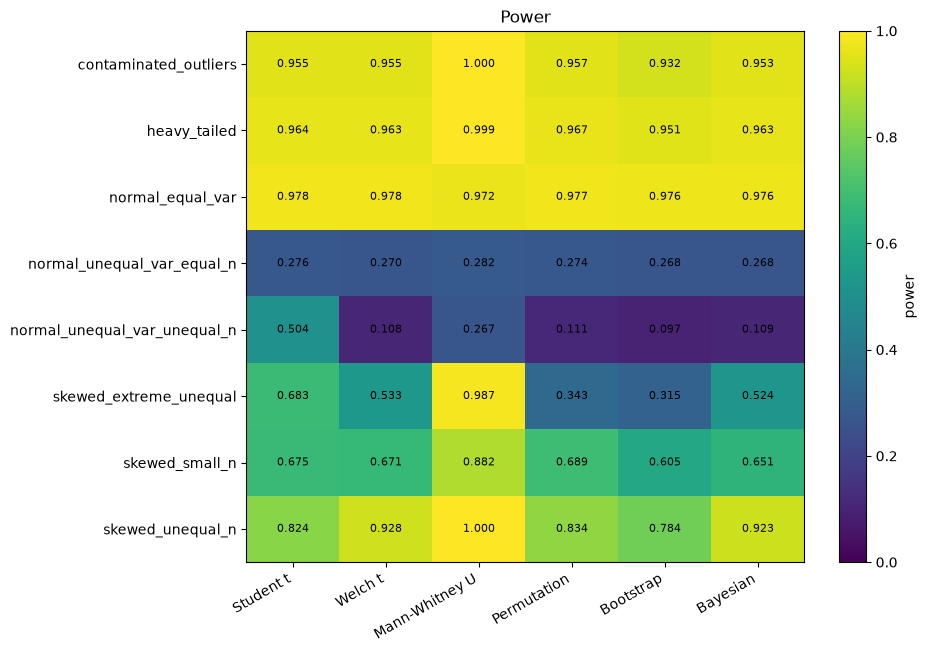

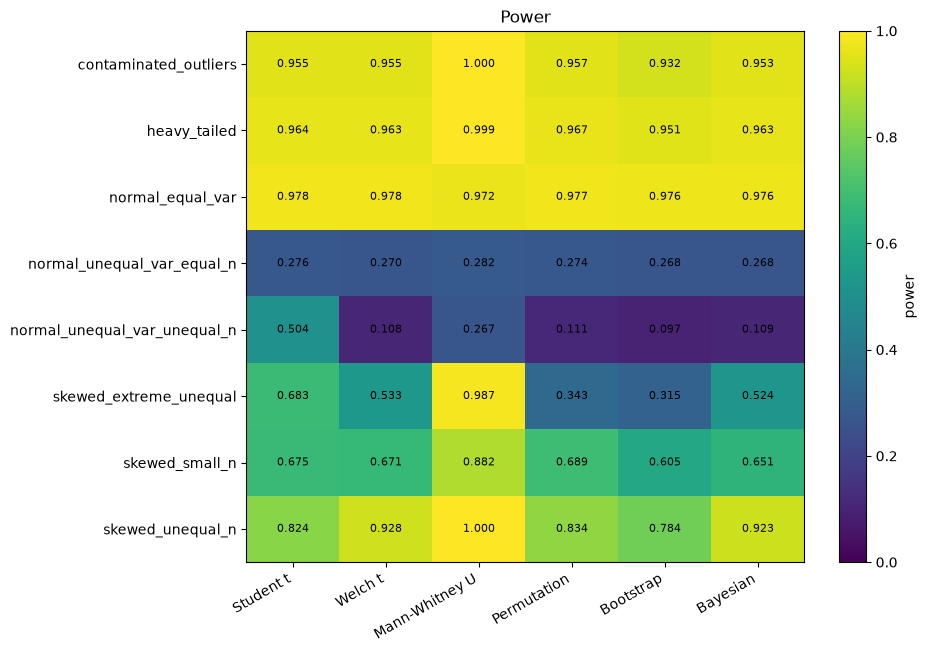

In [7]:
fig = plot_arena_heatmap(arena, metric="power", alpha=alpha)
figures["power_heatmap"] = save_figure(fig, "04_power_heatmap")
fig

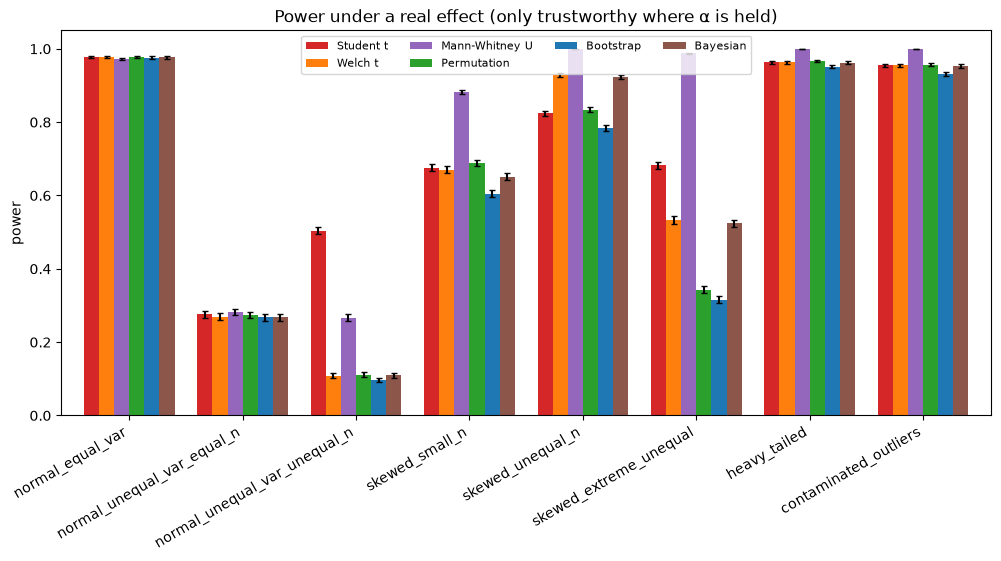

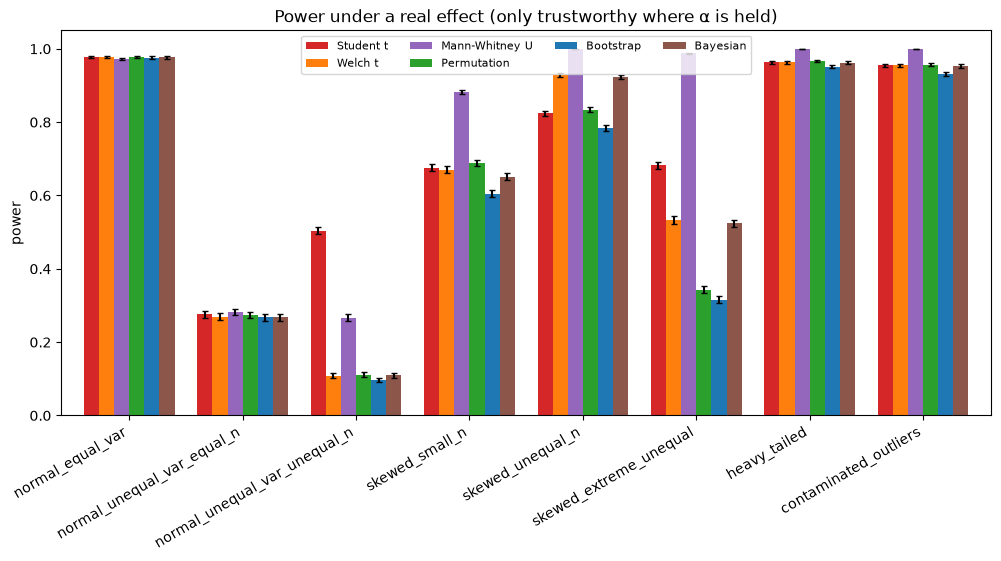

In [8]:
fig = plot_power(arena)
figures["power_bars"] = save_figure(fig, "04_power_bars")
fig

### The trap in this table

In `normal_unequal_var_unequal_n::effect`, Student's power is about five times Welch's. It would
be easy to read that as "Student is more powerful". It is not. Student is more *trigger-happy*:
on the matching null row it rejected 37.5% of the time. A test that rejects more often
regardless of whether anything is there will always look powerful, and the comparison is
meaningless unless both tests hold α first.

**Power is only comparable between tests that are calibrated on the same data.**

A second caution: power is **not** comparable *across rows of different population kinds*. An
effect of 0.8 standard deviations means something different on a lognormal than on a normal,
because a skewed distribution's standard deviation is inflated by its tail. Compare down a
column, never across the shapes.

## The verdict

In [9]:
summary_table = verdict(arena)
summary_table.round(3)

,worst_fpr,max_abs_deviation_se,n_inflated,n_conservative,mean_power
test,,,,,
student,0.375,67.183,2,2,0.732
welch,0.177,33.218,2,2,0.676
mann_whitney,0.342,61.487,3,1,0.799
permutation,0.130,23.810,1,0,0.644
bootstrap,0.159,29.847,2,3,0.616
bayesian,0.172,32.290,2,2,0.671


Reading the columns:

- `worst_fpr` — the highest false-positive rate the test produced anywhere in the grid.
- `max_abs_deviation_se` — how far from α it strayed, in Monte Carlo standard errors.
- `n_inflated` / `n_conservative` — null cells more than 3 SE above / below α. These are counted
  separately on purpose: inflation invents discoveries, conservatism only spends power, and one
  of those is much more expensive than the other.
- `mean_power` — average power across the effect scenarios, meaningful only alongside the rest.

## The honest verdict

**The permutation test is the only contender with a single inflated cell**, and that cell is the
extreme-skew scenario where nothing works. Everywhere else in this grid it sits on α without
being told anything about the data.

**Welch is the right default among the parametric tests** and a free upgrade over Student — but
it is not bulletproof: on skewed unbalanced data it is the one running hot.

**Student is the least reliable of the six** precisely where data is least well-behaved, and it
is fine exactly where textbooks demonstrate it.

**The bootstrap never invents discoveries here**, but pays for it with conservatism on skewed
and contaminated data — a real cost, in power, that should be stated rather than hidden.

**Mann-Whitney has the highest mean power** in this grid and answers a different question. Both
of those are true at once, and the second is why the first is not a recommendation.

Next: how much data each test needs, and what a non-significant result actually means.

In [10]:
nulls = arena[arena["metric"] == "fpr"]
worst = nulls.loc[nulls["reject_rate"].idxmax()]
best_test = summary_table["n_inflated"].idxmin()

summary = {
    "notebook": "04_arena",
    "settings": {"profile": settings.profile, "alpha": alpha, "n_reps": n_reps,
                 "n_perm": settings.reps.n_perm, "n_boot": settings.reps.n_boot,
                 "n_posterior": settings.reps.n_posterior, "seed": settings.seed},
    "arena": arena,
    "false_positive_scoreboard": scoreboard(arena, "fpr").reset_index(),
    "power_scoreboard": scoreboard(arena, "power").reset_index(),
    "verdict": summary_table.reset_index(),
    "worst_cell": {
        "scenario": worst["scenario"], "test": worst["test"],
        "false_positive_rate": worst["reject_rate"], "times_alpha": worst["reject_rate"] / alpha,
    },
    "figures": figures,
    "claims": [
        f"Across {nulls['scenario'].nunique()} null conditions and 6 tests, the worst "
        f"false-positive rate was {worst['reject_rate']:.3f} "
        f"({worst['reject_rate'] / alpha:.1f}x alpha), from {worst['test']} on "
        f"{worst['scenario']}.",
        f"The permutation test had the fewest inflated null cells "
        f"({int(summary_table.loc['permutation', 'n_inflated'])} of "
        f"{nulls['scenario'].nunique()}), all others had more.",
        "Student's apparent power advantage under unequal variance with unequal n is an "
        "artifact of its broken false-positive rate, not a real advantage.",
        "Power is not comparable across population kinds, because Cohen's d divides by a "
        "standard deviation that a skewed distribution's tail inflates.",
        "Under extreme skew concentrated in the smaller group, no mean-based test in the arena "
        "holds alpha; the permutation test is merely the least-bad.",
        f"Least-inflated contender overall: {best_test}.",
    ],
}
print(save_results("04_arena", summary))

/workspaces/hypothesis_testing_arena/outputs/results/04_arena.json
